In [ ]:
# Подключение локальной библиотеки src/rsdocs
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd() / "src"))

from src.rsdocs import data, metrics, infer, compare
from src.rsdocs.prompts import OCRPrompts, TextBBoxPrompts



### Qwen3-VL — Before/After Comparison

Назначение — сравнение качества базовой и дообученной моделей на синтетических документах.

- **Входные данные**: изображения и JSON в каталоге `out/`.
- **Выход**: три CSV с предсказаниями и сравнением, графики распределений и scatter.



In [5]:
%%capture
# Минимальные зависимости для сравнения
%pip install --quiet transformers pillow matplotlib
# Если нужен unsloth/trl/peft — раскомментируйте:
# %pip install --quiet --no-deps unsloth trl peft bitsandbytes accelerate



huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [6]:
import os, json, glob, random, re, csv
from typing import List, Dict
from PIL import Image
import matplotlib.pyplot as plt

OUT_DIR = "/home/user/workspace/re-synthetic-docs/data"
SEED = 3407

random.seed(SEED)

# Загрузка синтетических документов

def load_syntheticdocs(out_dir: str = OUT_DIR, max_samples: int | None = None, max_chars: int = 4000):
    data = []
    for jpath in sorted(glob.glob(os.path.join(out_dir, "*.json"))):
        try:
            with open(jpath, "r", encoding="utf-8") as f:
                meta = json.load(f)
            text = (meta.get("text") or "").strip()
            if not text:
                continue
            if len(text) > max_chars:
                text = text[:max_chars]
            stem = os.path.splitext(os.path.basename(jpath))[0]
            ppath = os.path.join(out_dir, stem + ".png")
            if not os.path.exists(ppath):
                continue
            img = Image.open(ppath).convert("RGB")
            data.append({"image": img, "text": text, "id": stem, "type": meta.get("type")})
            if max_samples and len(data) >= max_samples:
                break
        except Exception:
            continue
    return data

dataset = load_syntheticdocs()
print(f"Loaded samples: {len(dataset)}")

# Хелперы нормализации и метрик

def normalize_text(s: str) -> str:
    s = s.strip()
    s = re.sub(r"\s+", " ", s)
    return s

def levenshtein_distance(a: str, b: str) -> int:
    n, m = len(a), len(b)
    if n == 0: return m
    if m == 0: return n
    prev = list(range(m + 1))
    cur = [0] * (m + 1)
    for i in range(1, n + 1):
        cur[0] = i
        ai = a[i - 1]
        for j in range(1, m + 1):
            cost = 0 if ai == b[j - 1] else 1
            cur[j] = min(cur[j - 1] + 1, prev[j] + 1, prev[j - 1] + cost)
        prev, cur = cur, prev
    return prev[m]



Loaded samples: 110


### Prompt policy
Мы хотим от модели строго выводить только распознанный текст документа, без комментариев и лишних префиксов — для корректного сравнения EM/CER.



In [7]:
INSTR_OCR_STRICT = (
    "Внимательно распознай весь печатный текст на изображении. "
    "Выведи ТОЛЬКО распознанный текст без каких-либо комментариев, разметки, префиксов и кавычек. "
    "Сохраняй порядок строк и знаки препинания. Если символ неразборчив, не выдумывай его."
)
print(INSTR_OCR_STRICT)



Внимательно распознай весь печатный текст на изображении. Выведи ТОЛЬКО распознанный текст без каких-либо комментариев, разметки, префиксов и кавычек. Сохраняй порядок строк и знаки препинания. Если символ неразборчив, не выдумывай его.


Eval samples: 100
==((====))==  Unsloth 2025.10.12: Fast Qwen3_Vl patching. Transformers: 4.57.1. vLLM: 0.8.5.post1.
   \\   /|    NVIDIA GeForce RTX 3090 Ti. Num GPUs = 2. Max memory: 23.555 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.6. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.41it/s]


**Служебная записка № 16/972/59/11**
**Статус**: Открыто
Организация: ОАО «Наумов, Емельянов и Белозерова»
Подразделение/Направление: Контроль и диагностика в транспортных системах (авиа
Даты:
Приёмка: 27.09.2025
Отправка: 02.10.2025
Адреса
**Коммерческое предложение № 95/496/36/92**
**Статус**: Закрыто

**Компания**: НПО «Быков»
**Направление**: Контроль и диагностика в транспортных системах (авиация, автомо
**Дата**: 11.10.2025

**Контакты**: п. Кинешма, бул. Саратовский, д. 727, 1108
Вот пример **счёта-фактуры** в бухгалтерском стиле, соответствующий вашему описанию.

---

**СЧЁТ-ФАКТУРА**

**№ 42/119/99/51**

**Статус:** Открыто

**Поставщик:**

**Групп Евдокимов**

Адрес: с. Азов (Рост.), ул. Курская, д. 7/4 стр. 14, 429873


**ДОГОВОР АРЕНДЫ № 73/970/11/10**
**СТАТУС: ЗАКРЫТО**

г. Москва
"__" __________ 2025 г.

**Арендодатель**:
Закрытое акционерное общество «Шашков Лапин» (далее — Арендодатель), ИНН 771303820912, ОГРН 1127746757211, адрес
СЧЁТ-ФАКТУРА № 62/110/31/48**
Статус:*

Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.10it/s]


**Служебная записка № 16/972/59/11**  
**Статус**: Открыто  

Организация: ОАО «Наумов, Емельянов и Белозерова»  
Подразделение/Направление: Контроль и диагностика в транспортных системах (авиа)  

Даты:  
Приёмка: 27.09.2025  
Отправка: 02.10.2025  


**Коммерческое предложение № 95/496/36/92**  
**Статус**: Закрыто  

**Компания**: НПО «Быков»  
**Направление**: Контроль и диагностика в транспортных системах (авиация, автомо  
**Дата**: 11.10.2025  

**Контакты**: п. Кинешма, бул. Саратовский, д. 727, 110
Вот пример **счёта-фактуры** в бухгалтерском стиле, соответствующий вашему описанию:

---

**СЧЁТ-ФАКТУРА**  
**№ 42/119/99/51**  
**Статус:** Открыто  

**Поставщик:**  
**Групп Евдокимов**  
Адрес: с. Азов (Рост.), ул. Курская, д. 7/4 стр. 14, 4298
**ДОГОВОР АРЕНДЫ № 73/970/11/10**  
**СТАТУС: ЗАКРЫТО**  

г. Москва  
"___" __________ 2025 г.  

**Арендодатель**:  
Закрытое акционерное общество «Шашков Лапин» (далее — Арендодатель),  
ИНН 771303820912, ОГРН 112774675721
СЧЁТ-ФАКТУ

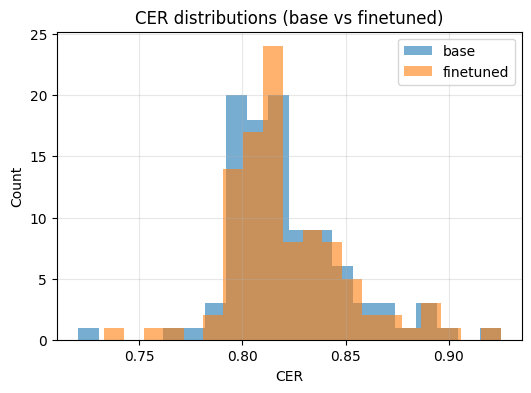

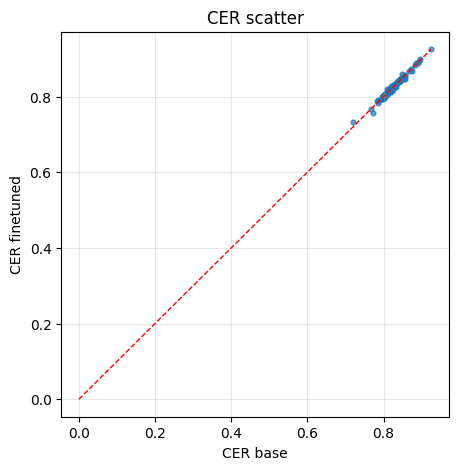

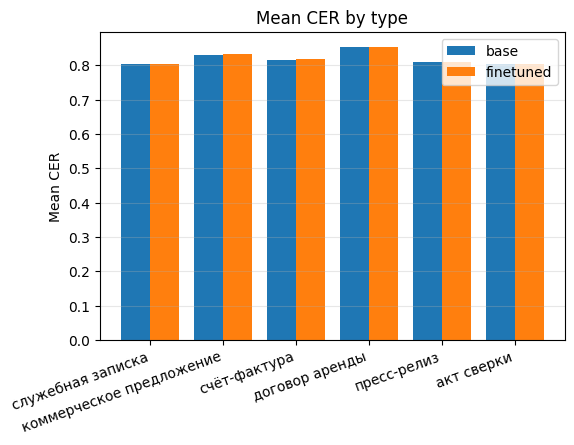

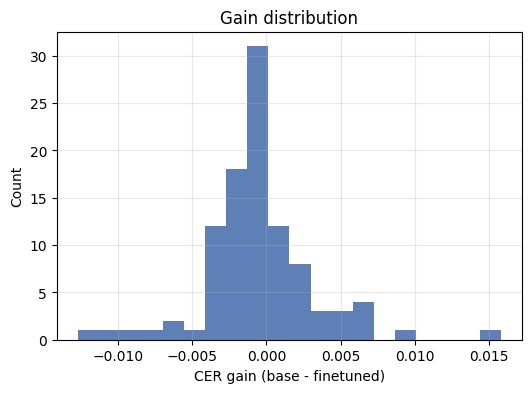

In [8]:
from unsloth import FastVisionModel
import torch
from transformers import TextStreamer

MODEL_NAME = "unsloth/Qwen3-VL-8B-Instruct-unsloth-bnb-4bit"
LORA_DIR = "/home/user/workspace/re-synthetic-docs/models/lora_model"


def build_inputs(tokenizer, image, instruction: str):
    messages = [{"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction},
    ]}]
    input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True)
    inputs = tokenizer(
        image,
        input_text,
        add_special_tokens=False,
        return_tensors="pt",
    ).to("cuda")
    return inputs


def run_eval(model, tokenizer, dataset, eval_indices, instruction: str, max_new_tokens: int = 128):
    FastVisionModel.for_inference(model)
    rows = []
    exact = 0
    cers = []
    for idx in eval_indices:
        sample = dataset[idx]
        gt = normalize_text(sample["text"])
        inputs = build_inputs(tokenizer, sample["image"], instruction)
        streamer = TextStreamer(tokenizer, skip_prompt=True)
        outputs = model.generate(
            **inputs,
            streamer=streamer,
            max_new_tokens=max_new_tokens,
            use_cache=True,
            temperature=1.2,
            min_p=0.1,
        )
        pred = normalize_text(tokenizer.decode(outputs[0], skip_special_tokens=True))
        em = int(pred == gt)
        cer = levenshtein_distance(pred, gt) / max(len(gt), 1)
        rows.append({
            "id": sample.get("id", str(idx)),
            "type": sample.get("type"),
            "gt": gt,
            "pred": pred,
            "em": em,
            "cer": cer,
        })
        exact += em
        cers.append(cer)
    return rows, exact / len(eval_indices), sum(cers) / len(eval_indices)


# Общая валидационная выборка
num_eval = min(100, len(dataset))
eval_indices = random.sample(range(len(dataset)), num_eval)
print(f"Eval samples: {num_eval}")

# 1) База: грузим базовую модель и считаем
model_base, tok_base = FastVisionModel.from_pretrained(
    MODEL_NAME,
    load_in_4bit=True,
    use_gradient_checkpointing="unsloth",
    device_map="balanced",
)
rows_base, em_base, cer_base = run_eval(model_base, tok_base, dataset, eval_indices, INSTR_OCR_STRICT)
base_csv = "/home/user/workspace/re-synthetic-docs/out/val_predictions_base.csv"
with open(base_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["id", "type", "gt", "pred", "em", "cer"])
    writer.writeheader(); writer.writerows(rows_base)
print(f"Saved base CSV: {base_csv}")

del model_base; torch.cuda.empty_cache()

# 2) Дообученная: используем текущую модель (если есть) или грузим из lora_model
try:
    model_ft = model  # если уже в памяти
    tok_ft = tokenizer
    _ = FastVisionModel.for_inference(model_ft)
except Exception:
    model_ft, tok_ft = FastVisionModel.from_pretrained(
        LORA_DIR,
        load_in_4bit=True,
        device_map="balanced",
    )

rows_ft, em_ft, cer_ft = run_eval(model_ft, tok_ft, dataset, eval_indices, INSTR_OCR_STRICT)
ft_csv = "/home/user/workspace/re-synthetic-docs/out/val_predictions_finetuned.csv"
with open(ft_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["id", "type", "gt", "pred", "em", "cer"])
    writer.writeheader(); writer.writerows(rows_ft)
print(f"Saved finetuned CSV: {ft_csv}")

# 3) Аггрегация и сравнение
base_by_id = {r["id"]: r for r in rows_base}
ft_by_id = {r["id"]: r for r in rows_ft}
joined = []
for idx in eval_indices:
    sid = dataset[idx].get("id", str(idx))
    b = base_by_id.get(sid)
    t = ft_by_id.get(sid)
    if not b or not t:
        continue
    joined.append({
        "id": sid,
        "type": b.get("type"),
        "gt": b["gt"],
        "pred_base": b["pred"],
        "pred_ft": t["pred"],
        "em_base": b["em"],
        "em_ft": t["em"],
        "cer_base": b["cer"],
        "cer_ft": t["cer"],
        "cer_gain": b["cer"] - t["cer"],
    })

cmp_csv = "/home/user/workspace/re-synthetic-docs/out/val_comparison_base_vs_ft.csv"
with open(cmp_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=[
        "id","type","gt","pred_base","pred_ft","em_base","em_ft","cer_base","cer_ft","cer_gain"
    ])
    writer.writeheader(); writer.writerows(joined)
print(f"Saved comparison CSV: {cmp_csv}")

print(f"EM base={em_base:.3%} -> finetuned={em_ft:.3%} (Δ={em_ft-em_base:+.3%})")
print(f"CER base={cer_base:.3f} -> finetuned={cer_ft:.3f} (Δ={cer_ft-cer_base:+.3f})")

# Графики: распределения и scatter
cer_b = [r["cer_base"] for r in joined]
cer_t = [r["cer_ft"] for r in joined]

plt.figure(figsize=(6,4))
plt.hist(cer_b, bins=20, alpha=0.6, label="base")
plt.hist(cer_t, bins=20, alpha=0.6, label="finetuned")
plt.xlabel("CER"); plt.ylabel("Count"); plt.title("CER distributions (base vs finetuned)")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

plt.figure(figsize=(5,5))
plt.scatter(cer_b, cer_t, s=12, alpha=0.7)
mx = max(cer_b + cer_t) if joined else 1.0
plt.plot([0,mx],[0,mx],"r--",linewidth=1)
plt.xlabel("CER base"); plt.ylabel("CER finetuned"); plt.title("CER scatter")
plt.grid(True, alpha=0.3); plt.show()

# По типам документов (если есть)
from collections import defaultdict
by_type = defaultdict(lambda: {"b":[], "t":[]})
for r in joined:
    by_type[r.get("type")]["b"].append(r["cer_base"])
    by_type[r.get("type")]["t"].append(r["cer_ft"])

labels, mbase, mft = [], [], []
for k,v in by_type.items():
    if not v["b"] or not v["t"]:
        continue
    labels.append(str(k))
    mbase.append(sum(v["b"]) / len(v["b"]))
    mft.append(sum(v["t"]) / len(v["t"]))

if labels:
    import numpy as np
    x = np.arange(len(labels))
    w = 0.4
    plt.figure(figsize=(max(6, len(labels)*0.8),4))
    plt.bar(x - w/2, mbase, width=w, label="base")
    plt.bar(x + w/2, mft,   width=w, label="finetuned")
    plt.xticks(x, labels, rotation=20, ha="right")
    plt.ylabel("Mean CER"); plt.title("Mean CER by type")
    plt.legend(); plt.grid(True, axis="y", alpha=0.3)
    plt.show()

# Распределение выигрыша
gains = [r["cer_gain"] for r in joined]
plt.figure(figsize=(6,4))
plt.hist(gains, bins=20, color="#4C72B0", alpha=0.9)
plt.xlabel("CER gain (base - finetuned)"); plt.ylabel("Count")
plt.title("Gain distribution")
plt.grid(True, alpha=0.3)
plt.show()

